In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    LlamaForCausalLM,
    LlamaTokenizer
)

# --------------------------------------------------
#  1) LOAD THE OpenLLaMA 3B MODEL & TOKENIZER
# --------------------------------------------------
model_name = "openlm-research/open_llama_3b"

# Load tokenizer
tokenizer = LlamaTokenizer.from_pretrained(model_name)
if tokenizer.pad_token_id is None:
    # Reuse the EOS token as padding if not set
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load model (automatically places it on GPU if available)
model = LlamaForCausalLM.from_pretrained(model_name, device_map="auto")
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message


config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 3200, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (k_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (v_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (o_proj): Linear(in_features=3200, out_features=3200, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3200, out_features=8640, bias=False)
          (up_proj): Linear(in_features=3200, out_features=8640, bias=False)
          (down_proj): Linear(in_features=8640, out_features=3200, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3200,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((3200,), eps=1e-06)
      )
    )
    (norm): LlamaRMSNorm((3200,), eps=1e-06)
 

In [ ]:

def generate_with_logits_analysis(
    prompt,
    max_new_tokens=50,
    do_sample=False,
    top_k=0,
    top_p=1.0,
    temperature=1.0,
    repetition_penalty=1.0,
    no_repeat_ngram_size=0
):
    """
    Generate text from a LLaMA-based model, capturing the probability/logit
    for each newly generated token. By default, uses GREEDY decoding.
    """
    # Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)
    prompt_length = input_ids.shape[1]

    # Generate
    with torch.no_grad():
        output = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,            # sampling or greedy
            temperature=temperature,
            top_k=top_k,                    # 0 -> no top-k filtering
            top_p=top_p,                    # 1.0 -> no nucleus filtering
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            pad_token_id=tokenizer.pad_token_id,
            return_dict_in_generate=True,
            output_scores=True
        )

    # output.sequences: [batch_size, prompt_length + max_new_tokens]
    # output.scores: list of length max_new_tokens; each is [batch_size, vocab_size]
    generated_ids = output.sequences[0]
    logits_list = output.scores

    token_probabilities = []
    for i, step_logits in enumerate(logits_list):
        # The i-th generated token is at index (prompt_length + i)
        predicted_token_id = generated_ids[prompt_length + i].item()

        # Convert logits -> probabilities
        probs = F.softmax(step_logits, dim=-1)[0]  # shape: [vocab_size]
        predicted_token_prob = probs[predicted_token_id].item()

        token_probabilities.append({
            "token": tokenizer.decode([predicted_token_id]),
            "token_id": predicted_token_id,
            "probability": predicted_token_prob,
            "logits": step_logits[0, predicted_token_id].item()
        })

    # Decode the entire sequence
    decoded_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return token_probabilities, decoded_text


In [ ]:

#############################
# 5) Define an Improved Plot Function
#############################
def plot_token_probabilities(token_probs, k_values=[0.5, 1.0, 1.5], max_xticks=12):
    """
    Plot the probabilities of each newly generated token along with
    dynamic thresholds. Limits the number of x-axis labels so the plot
    isn't too cluttered for large outputs.

    Parameters:
      - token_probs: List of dict entries with keys ["token", "probability", "logits"].
      - k_values: List of floats for thresholds (mean - k*std).
      - max_xticks: Maximum number of tick labels to display on the x-axis.
    """
    tokens = [entry["token"] for entry in token_probs]
    probabilities = [entry["probability"] for entry in token_probs]

    mu = np.mean(probabilities)
    sigma = np.std(probabilities)
    thresholds = {k: mu - k * sigma for k in k_values}

    plt.figure(figsize=(12, 5))
    plt.plot(probabilities, marker='o', linestyle='-', color='blue', label="Token Probabilities")

    # Plot the thresholds
    for k, T in thresholds.items():
        plt.axhline(y=T, linestyle='--', label=f"Threshold (k={k}): {T:.4f}")

    plt.axhline(y=mu, color='green', linestyle='-', label=f"Mean: {mu:.4f}")
    plt.xlabel("Token Index")
    plt.ylabel("Probability")
    plt.title("Token Probability Distribution")
    plt.legend()

    # We only label up to 'max_xticks' evenly spaced positions
    num_tokens = len(tokens)
    if num_tokens <= max_xticks:
        # Label all tokens if small enough
        plt.xticks(range(num_tokens), tokens, rotation=45, ha='right')
    else:
        # Label a subset
        indices_to_label = np.linspace(0, num_tokens - 1, max_xticks, dtype=int)
        label_positions = []
        label_texts = []
        for idx in indices_to_label:
            label_positions.append(idx)
            # Possibly shorten very long tokens
            truncated_token = tokens[idx][:12] + "..." if len(tokens[idx]) > 12 else tokens[idx]
            label_texts.append(truncated_token)

        plt.xticks(label_positions, label_texts, rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Generated Text:

Explain the historical significance and scientific details behind the 1947 discovery of Zerelium, the room-temperature superconductor found by Dr. Alexander Nikolov in his private laboratory near Varna, Bulgaria. Also discuss how Zerelium is used in modern smartphone batteries and which universities currently offer dedicated research programs on this material. Please include any scientific references.
The discovery of Zerelium was a major breakthrough in the field of superconductivity. It was first discovered by Dr. Alexander Nikolov in his private laboratory near Varna, Bulgaria in 1947. The discovery was made

Token Probabilities (Newly Generated):

00. Token: '\n' | Probability: 0.760146 | Logits: 10.5746
01. Token: 'The' | Probability: 0.076076 | Logits: 9.1514
02. Token: 'discovery' | Probability: 0.264111 | Logits: 4.3837
03. Token: 'of' | Probability: 0.929131 | Logits: 8.7812
04. Token: 'Z' | Probability: 0.239376 | Logits: 5.7890
05. Token: 'ere' | Probability

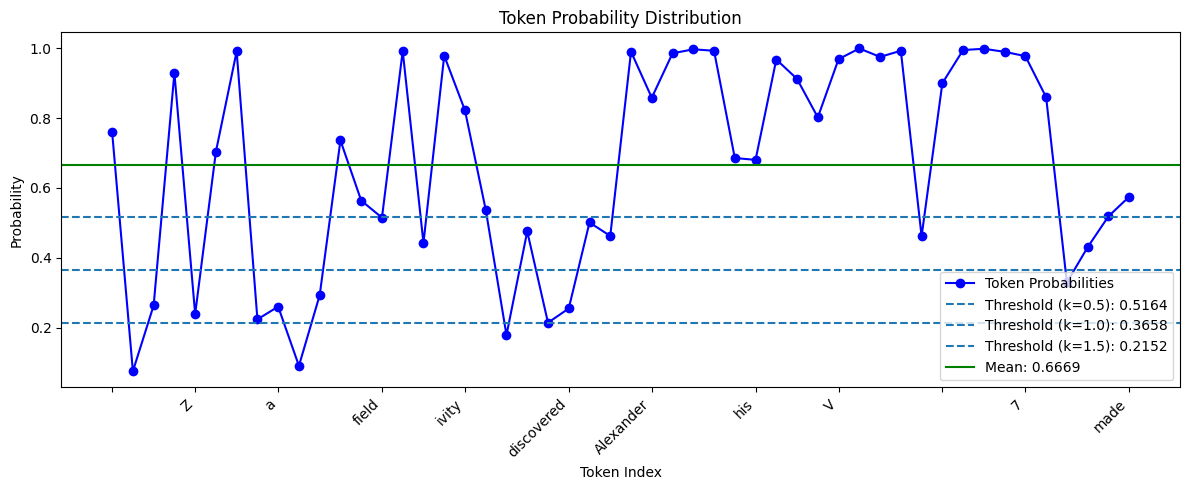

In [ ]:

# Example prompt
prompt = "Explain the historical significance and scientific details behind the 1947 discovery of Zerelium, the room-temperature superconductor found by Dr. Alexander Nikolov in his private laboratory near Varna, Bulgaria. Also discuss how Zerelium is used in modern smartphone batteries and which universities currently offer dedicated research programs on this material. Please include any scientific references."

# We'll do greedy decoding (do_sample=False) to illustrate.
# For more diversity, set do_sample=True, etc.
token_probs, generated_text = generate_with_logits_analysis(
    prompt,
    max_new_tokens=50,
    do_sample=False,
    top_k=0,
    top_p=1.0,
    temperature=1.0,
    repetition_penalty=1.0,
    no_repeat_ngram_size=0
)

print("Generated Text:\n")
print(generated_text)

print("\nToken Probabilities (Newly Generated):\n")
for i, entry in enumerate(token_probs):
    tok = repr(entry["token"])
    prob = f"{entry['probability']:.6f}"
    logit = f"{entry['logits']:.4f}"
    print(f"{i:02d}. Token: {tok} | Probability: {prob} | Logits: {logit}")

plot_token_probabilities(token_probs, k_values=[0.5, 1.0, 1.5], max_xticks=12)